# Project S2 Image Recognition  
## Smart Waste Sorting: Klasifikasi Sampah Berbasis Deep Learning + Wavelet + App Demo

**Main goal:** menggunakan teori/prinsip/teknik *voice and image recognition*, *deep learning*, *pre-processing*, *fine-tuning*, *hyperparameter tuning*, dan *explainable AI* untuk menyelesaikan masalah nyata serta menunjukkan peningkatan teknologi dalam bentuk aplikasi demo.

**Topik yang dipilih:** *Image Recognition untuk klasifikasi sampah rumah tangga*.

**Masalah nyata:** pemilahan sampah manual sering tidak konsisten. Aplikasi pengenalan gambar dapat membantu pengguna atau petugas memilah sampah menjadi kategori seperti `cardboard`, `glass`, `metal`, `paper`, `plastic`, dan `trash`.

**Bentuk solusi:** notebook ini membangun model klasifikasi gambar berbasis **transfer learning MobileNetV3**, ditambah opsi **wavelet preprocessing** untuk memisahkan komponen frekuensi rendah/tren dan frekuensi tinggi/fluktuasi, lalu model dipresentasikan sebagai **app demo Gradio**.

---

## Kontribusi / Improvement

Notebook ini tidak hanya melatih model standar, tetapi menambahkan beberapa elemen peningkatan:

1. **Transfer learning**: memakai backbone CNN pretrained sehingga lebih efisien dibanding training dari nol.
2. **Wavelet-based preprocessing**: mengekstrak komponen low-frequency dan high-frequency untuk membantu model melihat struktur global serta detail tepi/tekstur.
3. **Fine-tuning bertahap**: awalnya backbone dibekukan, lalu beberapa layer akhir dibuka.
4. **Hyperparameter tuning sederhana**: eksperimen learning rate, batch size, dan mode preprocessing.
5. **Explainable AI**: Grad-CAM untuk melihat area gambar yang memengaruhi prediksi.
6. **App demo**: Gradio upload gambar → prediksi kelas + confidence.

> Catatan: notebook ini siap dijalankan di Google Colab/Kaggle/local. Dataset dapat berupa folder gambar dengan struktur `ImageFolder`.

## 1. Setup Environment

Jalankan cell berikut. Untuk Google Colab, aktifkan GPU melalui:  
`Runtime → Change runtime type → GPU`.

In [1]:
# Cek GPU
import torch
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cpu
CUDA available: False


In [2]:
# Install dependency tambahan bila belum tersedia
# Di Colab biasanya torch/torchvision sudah ada.
!pip -q install gradio pywavelets scikit-learn matplotlib seaborn tqdm

In [3]:
import os
import random
import copy
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms, models

import pywt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


## 2. Dataset

Gunakan dataset klasifikasi sampah, misalnya **TrashNet** atau dataset sejenis dari Kaggle. Struktur folder yang direkomendasikan:

```text
dataset/
  cardboard/
    img001.jpg
    img002.jpg
  glass/
    img001.jpg
  metal/
  paper/
  plastic/
  trash/
```

Ubah variabel `DATA_DIR` sesuai lokasi dataset.

Contoh di Colab:

```python
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/MyDrive/dataset/trashnet'
```

### Download Dataset from Kaggle

To download the dataset from Kaggle, please ensure you have uploaded your `kaggle.json` file to your Colab environment. This file contains your API credentials.

First, you can uncomment and run the `!rm` command if you need to clear previous Kaggle credentials. Then, proceed to create the Kaggle directory, copy your `kaggle.json` file, and set appropriate permissions.


In [8]:
# If you have a kaggle.json from a previous session, you might want to remove it first
# !rm -f ~/.kaggle/kaggle.json

# Create .kaggle directory if it doesn't exist
!mkdir -p ~/.kaggle

# Copy kaggle.json to the directory (you need to upload it to Colab first)
# After uploading, you can right-click the file in the files sidebar and copy its path.
# Replace '/path/to/your/kaggle.json' with the actual path.
# For example, if you uploaded to the root, it would be '/content/kaggle.json'
!cp /content/kaggle.json ~/.kaggle/

# Set permissions for kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API setup complete. You can now download datasets.")

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API setup complete. You can now download datasets.


Now, download the `garbage-classification` dataset from Kaggle and unzip it into the `/content/dataset` directory, which matches your `DATA_DIR` variable. After extraction, it's a good practice to verify the contents of the directory.

In [13]:
global DATA_DIR # Declare DATA_DIR as global at the top of the cell

# Download the dataset to /content
!kaggle datasets download -d asdasdasasdas/garbage-classification -p /content

# Create the DATA_DIR if it doesn't exist
# Ensure /content/dataset exists as base for extraction
!mkdir -p {DATA_DIR}

# Unzip the dataset into a temporary location first, then move the correct subfolder
import zipfile
import os
from pathlib import Path

zip_path = '/content/garbage-classification.zip'
extract_base_dir = Path('/content/temp_dataset_extract') # Extract to a temp dir to control structure
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        print(f"Contents of {zip_path}:\n{zip_ref.namelist()[:5]}...") # Print first 5 items
        zip_ref.extractall(extract_base_dir) # Extract to temporary directory
    print(f"Dataset unzipped to {extract_base_dir}")
else:
    print(f"Error: {zip_path} not found. Kaggle download might have failed.")

# Find the deeply nested folder containing the actual class images
# Expected structure from this specific Kaggle dataset: temp_dataset_extract/Garbage classification/Garbage classification/class_folders
# We'll explicitly define the target path based on known dataset structure
expected_nested_path = extract_base_dir / 'Garbage classification' / 'Garbage classification'

# Standard class names to verify if we found the right level
expected_class_names = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

found_correct_data_root = False
if expected_nested_path.exists() and expected_nested_path.is_dir():
    # Check if this directory actually contains the expected class folders
    dirs_in_nested_path = [d.name for d in expected_nested_path.iterdir() if d.is_dir()]
    if all(cls in dirs_in_nested_path for cls in expected_class_names):
        # Clear the original DATA_DIR and move the contents from the nested path
        if DATA_DIR.exists() and any(DATA_DIR.iterdir()): # Only clear if not empty
            import shutil
            for item in DATA_DIR.iterdir(): # Remove existing content from DATA_DIR, not DATA_DIR itself
                if item.is_file(): os.remove(item)
                else: shutil.rmtree(item)

        # Move actual class folders from expected_nested_path to DATA_DIR
        for item in expected_nested_path.iterdir():
            shutil.move(str(item), str(DATA_DIR / item.name))
        print(f"Successfully moved class folders to {DATA_DIR}")
        found_correct_data_root = True
    else:
        print(f"Warning: {expected_nested_path} found, but does not contain all expected class folders. Found: {dirs_in_nested_path}")
else:
    print(f"Warning: Expected path {expected_nested_path} not found. Inspect extracted structure.")

# Clean up temporary extraction directory if it exists
if extract_base_dir.exists():
    import shutil
    shutil.rmtree(extract_base_dir)
    print(f"Cleaned up temporary extraction directory: {extract_base_dir}")

# Verify the dataset structure after potential moves
# DATA_DIR should already be set to /content/dataset from the previous definition
print('Final DATA_DIR:', DATA_DIR)
print('Exists:', DATA_DIR.exists())
if DATA_DIR.exists():
    class_folders_after_move = [p.name for p in DATA_DIR.iterdir() if p.is_dir()]
    print('Class folders:', class_folders_after_move)
    if not all(cls in class_folders_after_move for cls in expected_class_names):
        print("Warning: Some common class folders (cardboard, glass, etc.) were not found directly under DATA_DIR. Please check extraction.")
else:
    print('Dataset directory not properly set up.')


Dataset URL: https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification
License(s): copyright-authors
garbage-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Contents of /content/garbage-classification.zip:
['Garbage classification/Garbage classification/cardboard/cardboard1.jpg', 'Garbage classification/Garbage classification/cardboard/cardboard10.jpg', 'Garbage classification/Garbage classification/cardboard/cardboard100.jpg', 'Garbage classification/Garbage classification/cardboard/cardboard101.jpg', 'Garbage classification/Garbage classification/cardboard/cardboard102.jpg']...
Dataset unzipped to /content/temp_dataset_extract
Successfully moved class folders to /content/dataset
Cleaned up temporary extraction directory: /content/temp_dataset_extract
Final DATA_DIR: /content/dataset
Exists: True
Class folders: ['cardboard', 'glass', 'plastic', 'paper', 'trash', 'metal']


In [14]:
# Ubah path ini sesuai lokasi dataset Anda
DATA_DIR = Path('/content/dataset')  # contoh: Path('/content/drive/MyDrive/dataset/trashnet')

print('DATA_DIR:', DATA_DIR)
print('Exists:', DATA_DIR.exists())
if DATA_DIR.exists():
    print('Class folders:', [p.name for p in DATA_DIR.iterdir() if p.is_dir()])
else:
    print('Silakan upload/extract dataset lalu ubah DATA_DIR.')

DATA_DIR: /content/dataset
Exists: True
Class folders: ['cardboard', 'glass', 'plastic', 'paper', 'trash', 'metal']


### Alternatif: Download dataset dari Kaggle

Jika menggunakan Kaggle API di Colab:

1. Upload `kaggle.json` ke Colab.
2. Jalankan contoh berikut, lalu sesuaikan nama dataset.

```python
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d asdasdasasdas/garbage-classification -p /content
!unzip -q /content/garbage-classification.zip -d /content/dataset
```

Karena nama folder dataset Kaggle bisa berbeda-beda, cek folder hasil ekstraksi dengan `!find /content/dataset -maxdepth 2 -type d`.

## 3. Konsep: Wavelet untuk Image Recognition

Wavelet memecah gambar menjadi komponen frekuensi:

- **Low frequency / approximation**: informasi global, bentuk utama, tren visual.
- **High frequency / detail**: tepi, tekstur, noise, fluktuasi lokal.

Dalam konteks sampah, detail tekstur bisa membantu membedakan `paper` vs `plastic`, atau `glass` vs `metal`. Namun high-frequency juga bisa menangkap noise, sehingga perlu eksperimen.

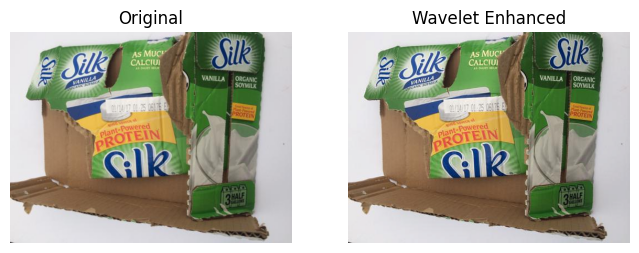

Sample: /content/dataset/cardboard/cardboard176.jpg


In [15]:
def wavelet_enhance_pil(img: Image.Image, wavelet='haar', detail_weight=1.5):
    """Menggabungkan low-frequency dan high-frequency wavelet sebagai preprocessing.
    Input/Output: PIL RGB image.
    """
    img = img.convert('RGB')
    arr = np.array(img).astype(np.float32) / 255.0
    out_channels = []

    for c in range(3):
        channel = arr[:, :, c]
        coeffs2 = pywt.dwt2(channel, wavelet)
        LL, (LH, HL, HH) = coeffs2
        # Tingkatkan detail high-frequency
        coeffs2_enhanced = (LL, (LH * detail_weight, HL * detail_weight, HH * detail_weight))
        rec = pywt.idwt2(coeffs2_enhanced, wavelet)
        rec = rec[:channel.shape[0], :channel.shape[1]]
        out_channels.append(rec)

    out = np.stack(out_channels, axis=-1)
    out = np.clip(out, 0, 1)
    return Image.fromarray((out * 255).astype(np.uint8))

# Demo wavelet pada satu gambar pertama bila dataset tersedia
if DATA_DIR.exists():
    image_files = list(DATA_DIR.glob('*/*'))
    image_files = [p for p in image_files if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp', '.webp']]
    if image_files:
        sample_path = image_files[0]
        img = Image.open(sample_path).convert('RGB')
        enhanced = wavelet_enhance_pil(img)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title('Original')
        plt.axis('off')
        plt.subplot(1, 2, 2)
        plt.imshow(enhanced)
        plt.title('Wavelet Enhanced')
        plt.axis('off')
        plt.show()
        print('Sample:', sample_path)

## 4. Preprocessing dan Augmentation

Augmentation membantu model lebih robust terhadap variasi dunia nyata: rotasi, pencahayaan, posisi objek, dan ukuran objek.

Kita buat dua mode:

- `baseline`: resize + augmentation standar.
- `wavelet`: gambar di-enhance menggunakan wavelet sebelum masuk ke model.

In [16]:
IMG_SIZE = 224
BATCH_SIZE = 32
VALID_RATIO = 0.15
TEST_RATIO = 0.15
USE_WAVELET = True  # set False untuk baseline standar

class WaveletTransform:
    def __init__(self, wavelet='haar', detail_weight=1.5):
        self.wavelet = wavelet
        self.detail_weight = detail_weight
    def __call__(self, img):
        return wavelet_enhance_pil(img, self.wavelet, self.detail_weight)

train_tfms_list = [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
]

if USE_WAVELET:
    train_tfms_list.append(WaveletTransform(detail_weight=1.3))

train_tfms_list += [
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]

val_tfms_list = [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
]
if USE_WAVELET:
    val_tfms_list.append(WaveletTransform(detail_weight=1.3))
val_tfms_list += [
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]

train_transform = transforms.Compose(train_tfms_list)
val_transform = transforms.Compose(val_tfms_list)

In [17]:
# Load dataset dan split train/valid/test
if not DATA_DIR.exists():
    raise FileNotFoundError('DATA_DIR belum ditemukan. Upload dataset dan set DATA_DIR terlebih dahulu.')

base_dataset = datasets.ImageFolder(DATA_DIR)
class_names = base_dataset.classes
num_classes = len(class_names)
print('Classes:', class_names)
print('Number of images:', len(base_dataset))

n_total = len(base_dataset)
n_test = int(TEST_RATIO * n_total)
n_val = int(VALID_RATIO * n_total)
n_train = n_total - n_val - n_test

train_subset, val_subset, test_subset = random_split(
    base_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Agar transform berbeda per split, buat wrapper dataset
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        path, label = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

train_ds = TransformSubset(train_subset, train_transform)
val_ds = TransformSubset(val_subset, val_transform)
test_ds = TransformSubset(test_subset, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print('Train/Val/Test:', len(train_ds), len(val_ds), len(test_ds))

Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Number of images: 2527
Train/Val/Test: 1769 379 379


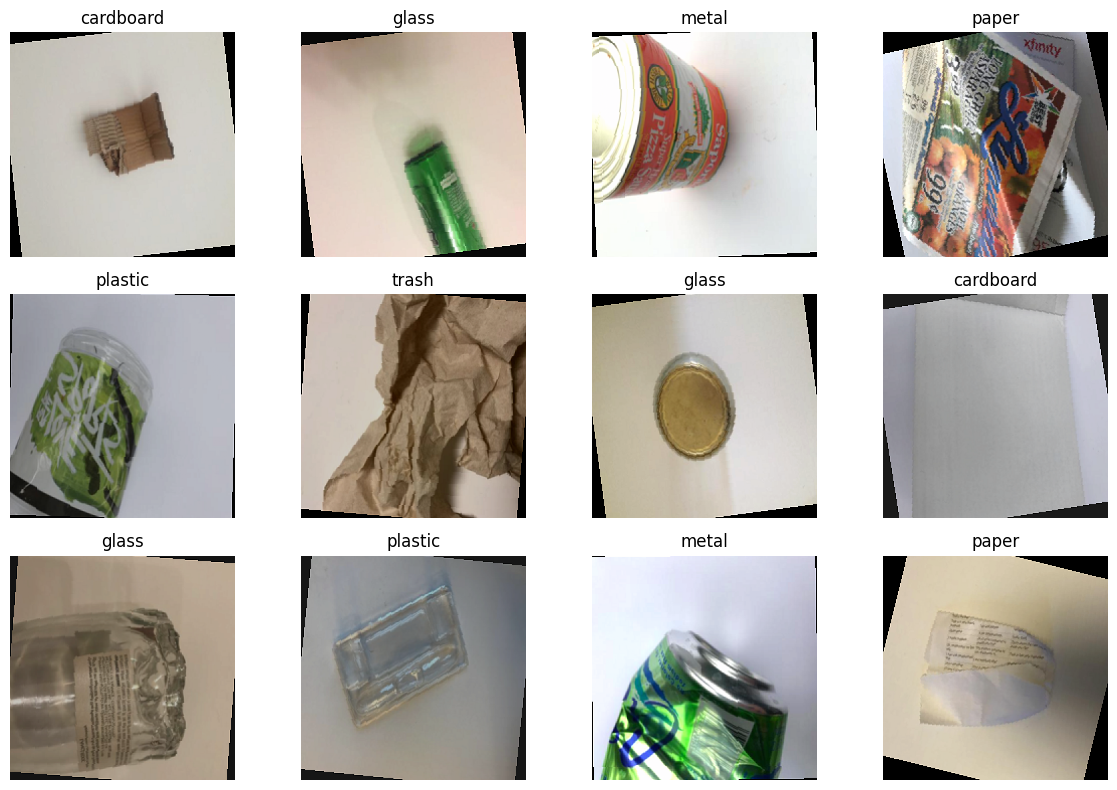

In [18]:
def denormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor.cpu() * std + mean

# Visualisasi batch training
images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 8))
for i in range(min(12, len(images))):
    plt.subplot(3, 4, i + 1)
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## 5. Model: MobileNetV3 Transfer Learning

**Kenapa MobileNetV3?**

- Ringan dan cocok untuk aplikasi mobile/web.
- Pretrained di ImageNet, sehingga sudah punya representasi fitur umum.
- Cocok untuk demo app karena inference relatif cepat.

Perbandingan konsep singkat:

- **CNN / Vision Transformer**: cocok untuk image recognition.
- **LSTM / BiLSTM**: cocok untuk data sekuensial, misalnya voice recognition, teks, atau time series. BiLSTM membaca dari dua arah sehingga memahami konteks sebelum dan sesudah.
- **LLM**: kuat untuk bahasa dan multimodal reasoning, tetapi untuk klasifikasi gambar ringan sering lebih efisien memakai CNN pretrained.
- **Diffusion model**: umumnya untuk generasi gambar, bukan pilihan utama untuk klasifikasi gambar, walau bisa dipakai untuk augmentasi sintetis.

In [19]:
def build_model(num_classes, freeze_backbone=True):
    weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
    model = models.mobilenet_v3_small(weights=weights)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

model = build_model(num_classes, freeze_backbone=True).to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 74.6MB/s]

Sequential(
  (0): Linear(in_features=576, out_features=1024, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1024, out_features=6, bias=True)
)


## 6. Training Utilities

Loss yang digunakan adalah **Cross Entropy Loss**, cocok untuk klasifikasi multi-kelas. Optimizer menggunakan **AdamW** karena stabil dan memiliki regularisasi weight decay.

In [21]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, total_correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, total_correct / total, np.array(all_labels), np.array(all_preds)


def fit(model, train_loader, val_loader, epochs=8, lr=1e-3, weight_decay=1e-4, patience=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    no_improve = 0

    for epoch in range(epochs):
        print(f'\nEpoch {epoch+1}/{epochs}')
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}')
        print(f'Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print('Early stopping triggered.')
                break

    model.load_state_dict(best_model_wts)
    return model, history

## 7. Tahap 1 Training: Frozen Backbone

Pada tahap ini, feature extractor dibekukan. Model hanya belajar classifier head, sehingga training lebih cepat dan risiko overfitting lebih kecil.

In [22]:
EPOCHS_STAGE1 = 8
LR_STAGE1 = 1e-3

model, history1 = fit(
    model, train_loader, val_loader,
    epochs=EPOCHS_STAGE1,
    lr=LR_STAGE1,
    weight_decay=1e-4,
    patience=3
)


Epoch 1/8


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

Train loss: 1.0004 | Train acc: 0.6326
Val   loss: 0.7290 | Val   acc: 0.7520

Epoch 2/8


Train:   0%|          | 0/56 [00:00<?, ?it/s]

...

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

Train loss: 0.3340 | Train acc: 0.8903
Val   loss: 0.5168 | Val   acc: 0.8179

Epoch 8/8


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

Train loss: 0.3210 | Train acc: 0.8836
Val   loss: 0.5425 | Val   acc: 0.8179


## 8. Tahap 2 Fine-tuning: Unfreeze Layer Akhir

Pada tahap ini, beberapa layer terakhir dibuka supaya model menyesuaikan fitur dengan domain sampah. Learning rate dibuat lebih kecil agar tidak merusak bobot pretrained.

In [23]:
# Buka beberapa blok terakhir pada MobileNetV3
for param in model.features[-3:].parameters():
    param.requires_grad = True

EPOCHS_STAGE2 = 6
LR_STAGE2 = 1e-4

model, history2 = fit(
    model, train_loader, val_loader,
    epochs=EPOCHS_STAGE2,
    lr=LR_STAGE2,
    weight_decay=1e-4,
    patience=3
)


Epoch 1/6


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f58ae7276a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f58ae7276a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f58ae7276a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
  Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7f58ae7276a0> 
  Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^    ^^self._shutdown_workers()^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
^   ^  ^ ^ ^^^^^^^^^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^^ ^ ^ ^
  File "/usr/lib/pyt

...

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

Train loss: 0.1656 | Train acc: 0.9480
Val   loss: 0.4032 | Val   acc: 0.8549

Epoch 6/6


Train:   0%|          | 0/56 [00:00<?, ?it/s]

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

Train loss: 0.1387 | Train acc: 0.9570
Val   loss: 0.4212 | Val   acc: 0.8496


## 9. Visualisasi Learning Curve

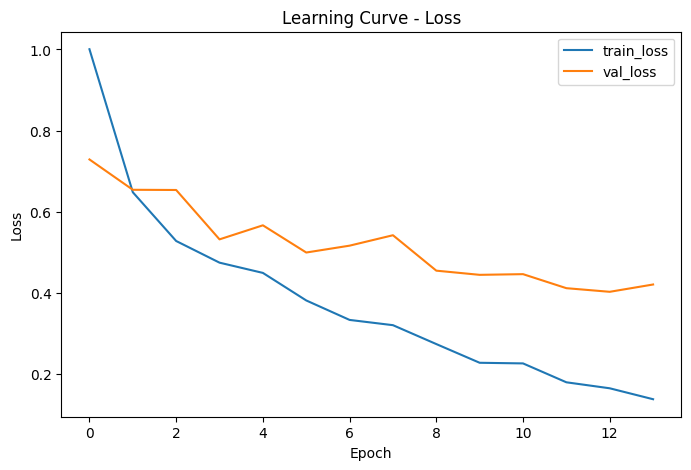

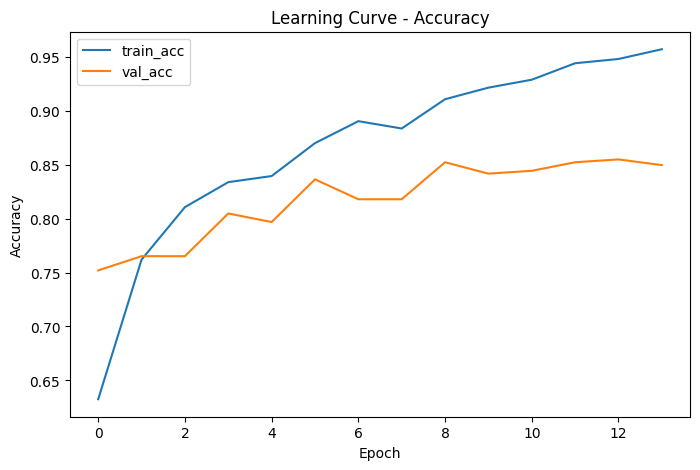

In [25]:
def concat_history(h1, h2):
    return {k: h1[k] + h2[k] for k in h1.keys()}

history = concat_history(history1, history2)

plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Learning Curve - Loss')
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Learning Curve - Accuracy')
plt.show()

## 10. Evaluasi pada Test Set

Metrik yang dipakai:

- **Accuracy**: proporsi prediksi benar.
- **Macro F1-score**: rata-rata F1 tiap kelas, penting jika dataset tidak seimbang.
- **Confusion Matrix**: melihat pasangan kelas yang sering tertukar.

In [26]:
criterion = nn.CrossEntropyLoss()
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion)
macro_f1 = f1_score(y_true, y_pred, average='macro')

print(f'Test loss : {test_loss:.4f}')
print(f'Test acc  : {test_acc:.4f}')
print(f'Macro F1  : {macro_f1:.4f}')
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=class_names))

Eval:   0%|          | 0/12 [00:00<?, ?it/s]

Test loss : 0.3540
Test acc  : 0.8734
Macro F1  : 0.8622

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.98      0.88      0.93        59
       glass       0.82      0.92      0.87        78
       metal       0.82      0.92      0.87        61
       paper       0.90      0.89      0.90        91
     plastic       0.88      0.80      0.84        66
       trash       0.85      0.71      0.77        24

    accuracy                           0.87       379
   macro avg       0.88      0.85      0.86       379
weighted avg       0.88      0.87      0.87       379



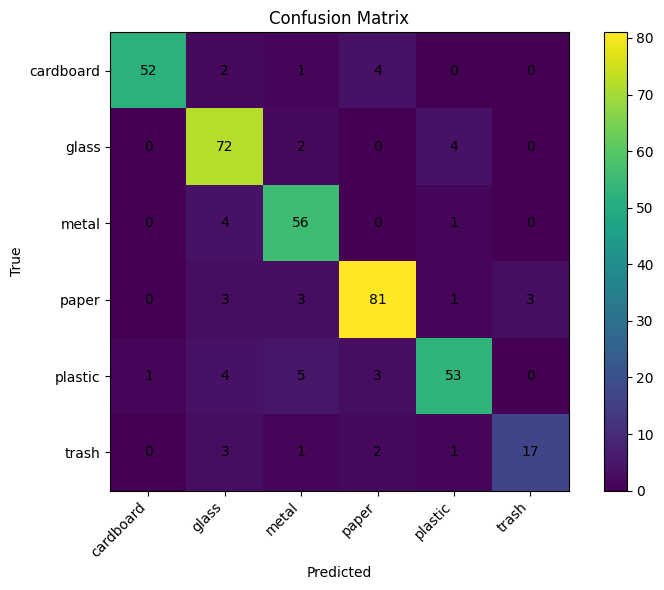

In [27]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(np.arange(num_classes), class_names, rotation=45, ha='right')
plt.yticks(np.arange(num_classes), class_names)
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.tight_layout()
plt.show()

## 11. Hyperparameter Tuning Sederhana

Eksperimen berikut dapat dijalankan untuk membandingkan konfigurasi. Untuk menghemat waktu, gunakan epoch kecil. Hasil terbaik dapat dipakai pada training final.

Parameter yang umum dicoba:

- `learning_rate`: 1e-3, 5e-4, 1e-4
- `batch_size`: 16, 32, 64
- `USE_WAVELET`: True/False
- `detail_weight` wavelet: 1.0, 1.3, 1.7
- optimizer: AdamW vs SGD momentum

> Catatan: cell ini opsional karena memerlukan waktu training beberapa kali.

In [28]:
# OPTIONAL: mini hyperparameter tuning
# Jalankan jika ingin membandingkan beberapa learning rate secara cepat.
RUN_TUNING = False

if RUN_TUNING:
    tuning_results = []
    for lr in [1e-3, 5e-4, 1e-4]:
        print('\nTuning LR:', lr)
        temp_model = build_model(num_classes, freeze_backbone=True).to(device)
        temp_model, temp_history = fit(
            temp_model, train_loader, val_loader,
            epochs=3,
            lr=lr,
            weight_decay=1e-4,
            patience=2
        )
        best_val_acc = max(temp_history['val_acc'])
        tuning_results.append({'lr': lr, 'best_val_acc': best_val_acc})
    tuning_results

## 12. Explainable AI: Grad-CAM

Grad-CAM membantu menjelaskan bagian gambar yang paling memengaruhi keputusan model. Ini penting untuk presentasi karena menunjukkan apakah model benar-benar melihat objek, bukan background.

In [29]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_layers()

    def hook_layers(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]
        heatmap = torch.mean(activations, dim=0).cpu().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap = heatmap / (heatmap.max() + 1e-8)
        return heatmap, class_idx

# Target layer terakhir dari feature extractor
cam = GradCAM(model, model.features[-1])

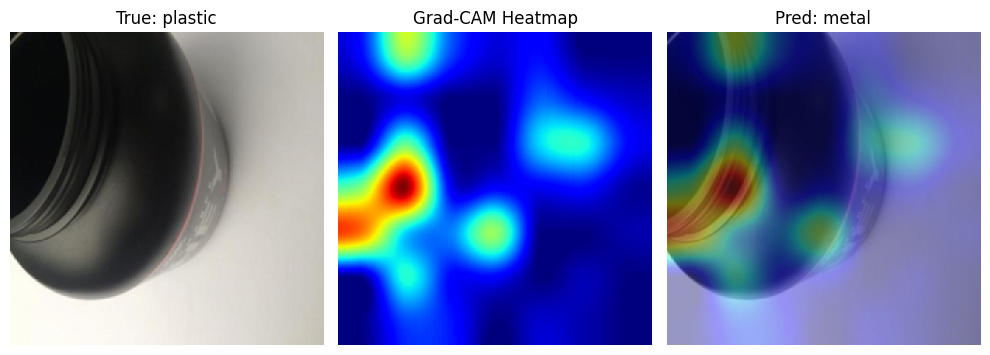

In [30]:
def show_gradcam_from_dataset(dataset, idx=0):
    img_tensor, label = dataset[idx]
    input_tensor = img_tensor.unsqueeze(0).to(device)
    heatmap, pred_idx = cam.generate(input_tensor)

    img = denormalize(img_tensor).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    heatmap_resized = Image.fromarray(np.uint8(255 * heatmap)).resize((IMG_SIZE, IMG_SIZE))
    heatmap_resized = np.array(heatmap_resized) / 255.0

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title(f'True: {class_names[label]}')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title('Grad-CAM Heatmap')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(img)
    plt.imshow(heatmap_resized, cmap='jet', alpha=0.4)
    plt.title(f'Pred: {class_names[pred_idx]}')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

show_gradcam_from_dataset(test_ds, idx=0)

## 13. Save Model

Model disimpan agar dapat dipakai ulang untuk deployment atau demo app.

In [31]:
SAVE_PATH = 'smart_waste_mobilenetv3_wavelet.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names,
    'img_size': IMG_SIZE,
    'use_wavelet': USE_WAVELET,
}, SAVE_PATH)
print('Saved to:', SAVE_PATH)

Saved to: smart_waste_mobilenetv3_wavelet.pth


## 14. App Demo dengan Gradio

Aplikasi menerima upload gambar sampah, melakukan preprocessing yang sama, lalu mengeluarkan prediksi kelas dan confidence.

Untuk presentasi, bagian ini adalah bukti bahwa solusi sudah berbentuk **app**.

In [32]:
import gradio as gr

# Transform inference
infer_tfms_list = [transforms.Resize((IMG_SIZE, IMG_SIZE))]
if USE_WAVELET:
    infer_tfms_list.append(WaveletTransform(detail_weight=1.3))
infer_tfms_list += [
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]
infer_transform = transforms.Compose(infer_tfms_list)

@torch.no_grad()
def predict_waste(image):
    if image is None:
        return {}
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    image = image.convert('RGB')
    x = infer_transform(image).unsqueeze(0).to(device)
    logits = model(x)
    probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

app = gr.Interface(
    fn=predict_waste,
    inputs=gr.Image(type='pil', label='Upload gambar sampah'),
    outputs=gr.Label(num_top_classes=3, label='Prediksi'),
    title='Smart Waste Sorting - Image Recognition App',
    description='Demo klasifikasi sampah berbasis MobileNetV3 + optional wavelet preprocessing.'
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ddc8b343d4a1eb7bcc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 15. Analisis Hasil untuk Laporan / Presentasi

Isi bagian ini setelah eksperimen dijalankan.

### Ringkasan eksperimen

| Komponen | Pilihan |
|---|---|
| Masalah | Klasifikasi sampah dari gambar |
| Model | MobileNetV3 Small pretrained |
| Preprocessing | Resize, augmentation, normalisasi, wavelet enhancement |
| Training | Frozen backbone lalu fine-tuning layer akhir |
| Metrik | Accuracy, Macro F1, confusion matrix |
| App | Gradio upload image classifier |

### Contoh narasi hasil

Model baseline MobileNetV3 sudah mampu mengenali pola visual umum karena pretrained di ImageNet. Setelah fine-tuning pada dataset sampah, model menyesuaikan fitur terhadap domain seperti tekstur plastik, kertas, kaca, dan logam. Wavelet preprocessing membantu menonjolkan komponen tepi dan tekstur. Namun, jika detail high-frequency terlalu kuat, model dapat lebih sensitif terhadap noise. Karena itu, nilai `detail_weight` perlu dituning.

### Insight dari confusion matrix

- Jika `plastic` sering tertukar dengan `trash`, kemungkinan dataset perlu ditambah contoh plastik kotor atau objek plastik dengan background beragam.
- Jika `glass` tertukar dengan `metal`, kemungkinan pantulan cahaya dan warna menjadi faktor dominan.
- Jika `paper` tertukar dengan `cardboard`, perlu resolusi atau cropping yang lebih baik agar tekstur permukaan terlihat.

### Insight dari Grad-CAM

Grad-CAM idealnya menunjukkan heatmap pada objek utama. Jika heatmap justru fokus pada background, solusi perbaikan adalah:

1. Menambah data dengan background beragam.
2. Menggunakan object detection/cropping sebelum klasifikasi.
3. Memakai segmentation untuk memisahkan objek sampah dari latar.

## 16. Rencana Pengembangan Lanjutan

1. **Object detection**: memakai YOLO untuk mendeteksi banyak sampah dalam satu gambar.
2. **Segmentation**: memakai U-Net/SAM untuk memisahkan objek dari background.
3. **Multimodal LLM**: pengguna bisa bertanya, “ini sampah apa dan cara membuangnya bagaimana?” lalu sistem menjawab dalam bahasa alami.
4. **Voice input**: menambahkan speech recognition agar pengguna bisa memberi instruksi suara, misalnya “klasifikasikan gambar ini”.
5. **Reinforcement learning / feedback loop**: pengguna memberi feedback benar/salah, lalu data feedback dipakai untuk retraining aktif.
6. **Edge deployment**: convert ke ONNX/TFLite agar dapat berjalan di perangkat mobile atau IoT.

---

## Kesimpulan

Proyek ini memenuhi tugas mata kuliah Image Recognition karena:

- Memilih topik image recognition yang nyata dan relevan.
- Membangun solusi deep learning berbasis transfer learning.
- Memakai preprocessing dan improvement berbasis wavelet.
- Melakukan fine-tuning dan evaluasi.
- Menyediakan explainability dengan Grad-CAM.
- Menghasilkan aplikasi demo berbasis Gradio.